# Redshift-Space Distortion (RSD) Sub-volume Corrections

In standard clustering, Subvolume subsampling severely artificialises the 1-halo spatial term. 
When working with Redshift-Space Distortions (RSD), peculiar velocities drastically stretch this 1-halo clustering along the line of sight (producing the classic "Fingers-of-God" effect). 

This notebook validates the `compute_weighted_rsd_multipoles` algorithm implemented in the module `galform_analysis.analysis.redshift_space_distortions.subvol_weighted_multipoles`.
We apply sub-vol weighting to isolate the expected Monopole ($\xi_0$) and Quadrupole ($\xi_2$), completely bypassing the substantial anisotropic smearing bias artificially introduced by subsampling!

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

# Add the GALFORM python source package
sys.path.append(str(Path("../../src").resolve()))

from galform_analysis.analysis.redshift_space_distortions.subvol_weighted_multipoles import (
    compute_weighted_rsd_multipoles,
)
from galform_analysis.utils.read_galaxies import read_galaxy_arrays
from galform_analysis.config import Cosmology, get_snapshot_redshift

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 13

## 1. Load Real GALFORM Galaxies (Lightweight Notebook Sample)
This section uses real GALFORM outputs (the same source tree used by the SLURM jobs), but only a small subset so it runs interactively.

We build redshift-space positions with:
- box position: $z$
- line-of-sight velocity: $v_z$ (`vzgal`)
- shift: $\Delta s_\parallel \approx v_z \; h / H(z)$ in $h^{-1}\,\mathrm{Mpc}$

Then we compare RSD multipoles for using 1 vs 2 vs 3 subvolumes.

In [2]:
# Data location (same family as SLURM workflows)
BASE_DIR = Path("/cosma5/data/durham/dc-hick2/Galform_Out/L800/lc16")
IZ = 155
BOXSIZE = 542.16
K_TOTAL = 1024

# Lightweight notebook settings
MAX_GAL_PER_SUBVOL = 3000
MHALO_MIN = 1e10
CENTRALS_ONLY = False
IVOLS_FOR_COMPARISON = [0, 1, 2]  # compare m=1,2,3 by taking first m ivols

# Convert z-position to redshift space with vzgal
z_snap = get_snapshot_redshift(f"iz{IZ}")
if z_snap is None:
    z_snap = 0.0

h = Cosmology.h
Ez = np.sqrt(Cosmology.OMEGA_M * (1.0 + z_snap) ** 3 + Cosmology.OMEGA_L)
H_z = 100.0 * h * Ez  # km/s/Mpc

print(f"Using {BASE_DIR}/iz{IZ}")
print(f"Snapshot redshift z={z_snap:.3f}, H(z)={H_z:.2f} km/s/Mpc")


def load_rsd_positions_for_ivols(ivols):
    pos_chunks = []
    label_chunks = []

    for label, ivol in enumerate(ivols):
        arrays, _ = read_galaxy_arrays(
            iz_path=str(BASE_DIR / f"iz{IZ}"),
            ivol=int(ivol),
            fields=["vzgal"],
            include_positions=True,
            include_derived=True,
            centrals_only=CENTRALS_ONLY,
            mhalo_min=MHALO_MIN,
        )

        x = arrays["x"]
        y = arrays["y"]
        z = arrays["z"]
        vz = arrays["vzgal"]

        # Randomly thin to keep the notebook fast and interactive
        n = len(x)
        if n > MAX_GAL_PER_SUBVOL:
            idx = np.random.choice(n, size=MAX_GAL_PER_SUBVOL, replace=False)
            x, y, z, vz = x[idx], y[idx], z[idx], vz[idx]

        ds_par = (vz / H_z) * h  # Mpc/h
        z_rsd = (z + ds_par) % BOXSIZE

        pos = np.column_stack([x, y, z_rsd])
        labels = np.full(pos.shape[0], label, dtype=np.int64)

        pos_chunks.append(pos)
        label_chunks.append(labels)

        print(f"ivol{ivol}: loaded {pos.shape[0]} galaxies")

    gal_pos = np.vstack(pos_chunks)
    gal_labels = np.concatenate(label_chunks)
    return gal_pos, gal_labels

Using /cosma5/data/durham/dc-hick2/Galform_Out/L800/lc16/iz155
Snapshot redshift z=1.496, H(z)=158.41 km/s/Mpc


## 2. Compute RSD Multipoles for 1, 2, and 3 Subvolumes
For each $m \in \{1,2,3\}$, we concatenate the first $m$ subvolumes, compute standard and corrected $\xi(s,\mu)$, and project to:
- monopole $\xi_0(s)$
- quadrupole $\xi_2(s)$

In [3]:
# Corrfunc binning (kept moderate for notebook runtime)
s_bins = np.logspace(-1, 1.4, 18)
mu_max = 1.0
n_mu_bins = 16

results_by_m = {}

for m in [1, 2, 3]:
    ivols = IVOLS_FOR_COMPARISON[:m]
    gal_pos, labels = load_rsd_positions_for_ivols(ivols)

    # Use a moderate random catalogue size for speed
    n_random = max(12000, int(2.5 * gal_pos.shape[0]))
    rand_pos = np.random.uniform(0.0, BOXSIZE, size=(n_random, 3))

    res = compute_weighted_rsd_multipoles(
        galaxy_pos=gal_pos,
        galaxy_labels=labels,
        random_pos=rand_pos,
        s_bins=s_bins,
        mu_max=mu_max,
        n_mu_bins=n_mu_bins,
        k_total=K_TOTAL,
        boxsize=BOXSIZE,
        nthreads=4,
    )

    results_by_m[m] = res
    print(
        f"m={m}: ngal={gal_pos.shape[0]}, nrand={n_random}, "
        f"alpha={res['alpha']:.6f}, beta={res['beta'] if np.isfinite(res['beta']) else np.nan}"
    )

ivol0: loaded 3000 galaxies
m=1: ngal=3000, nrand=12000, alpha=0.000977, beta=nan
ivol0: loaded 3000 galaxies
ivol1: loaded 3000 galaxies
m=2: ngal=6000, nrand=15000, alpha=0.001953, beta=1.998046875
ivol0: loaded 3000 galaxies
ivol1: loaded 3000 galaxies
ivol2: loaded 3000 galaxies
m=3: ngal=9000, nrand=22500, alpha=0.002930, beta=1.49853515625


## 3. Compare RSD for 1 vs 2 vs 3 Subvolumes
Solid lines show the standard estimator; dashed lines show the corrected estimator. Colors encode the number of included subvolumes ($m=1,2,3$).

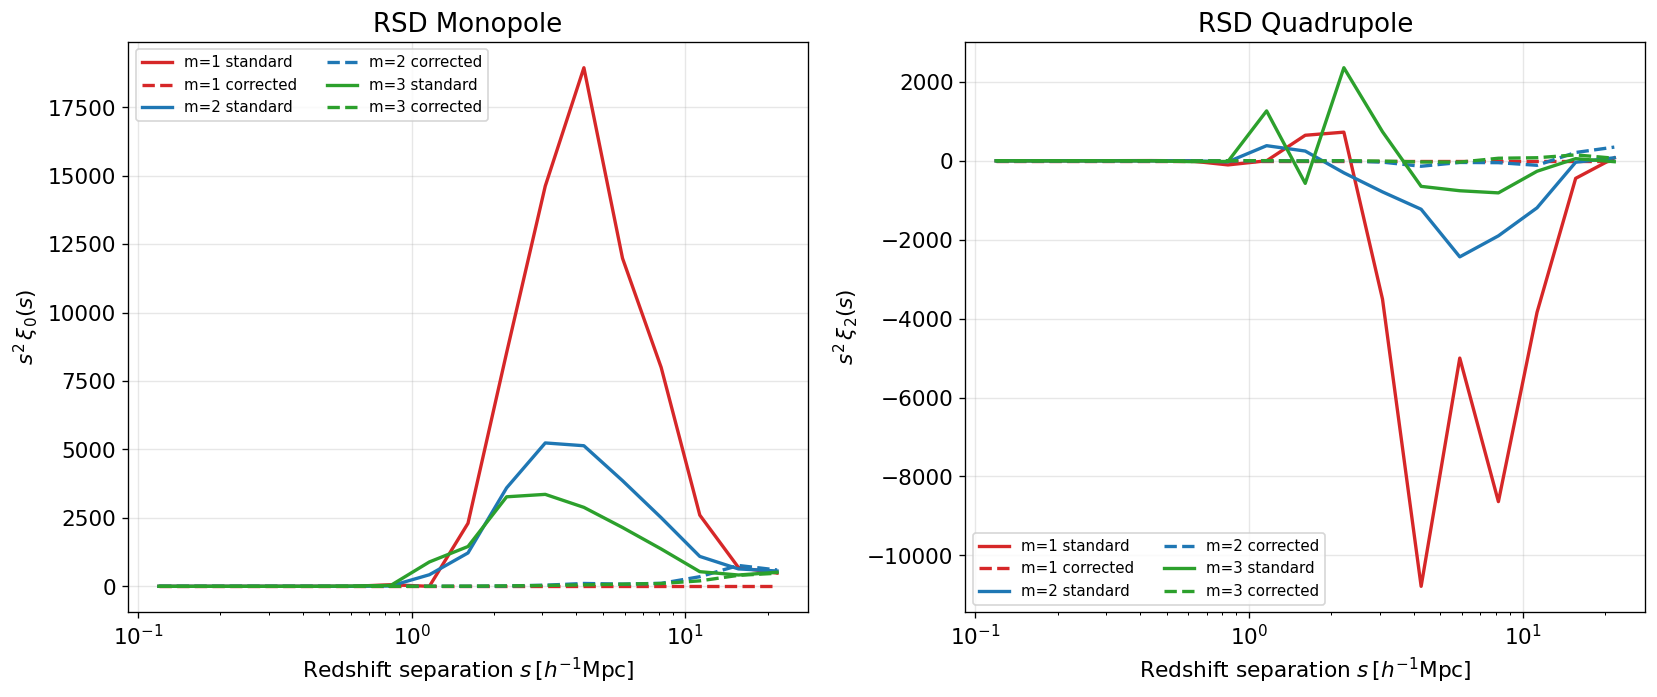

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharex=True)
colors = {1: "tab:red", 2: "tab:blue", 3: "tab:green"}

for m in [1, 2, 3]:
    res = results_by_m[m]
    s = res["s"]

    # Monopole
    ax1.plot(
        s,
        s**2 * res["xi0_standard"],
        color=colors[m],
        lw=2,
        ls="-",
        label=fr"m={m} standard",
    )
    ax1.plot(
        s,
        s**2 * res["xi0_corrected"],
        color=colors[m],
        lw=2,
        ls="--",
        label=fr"m={m} corrected",
    )

    # Quadrupole
    ax2.plot(
        s,
        s**2 * res["xi2_standard"],
        color=colors[m],
        lw=2,
        ls="-",
        label=fr"m={m} standard",
    )
    ax2.plot(
        s,
        s**2 * res["xi2_corrected"],
        color=colors[m],
        lw=2,
        ls="--",
        label=fr"m={m} corrected",
    )

ax1.set_xscale("log")
ax1.set_xlabel(r"Redshift separation $s\,[h^{-1}\mathrm{Mpc}]$")
ax1.set_ylabel(r"$s^2\,\xi_0(s)$")
ax1.set_title("RSD Monopole")
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=9, ncol=2)

ax2.set_xscale("log")
ax2.set_xlabel(r"Redshift separation $s\,[h^{-1}\mathrm{Mpc}]$")
ax2.set_ylabel(r"$s^2\,\xi_2(s)$")
ax2.set_title("RSD Quadrupole")
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=9, ncol=2)

plt.tight_layout()
plt.show()